# Tác tử thông minh: Tác tử phản xạ cho GridHunt

## Mục tiêu học tập

* Áp dụng các khái niệm AI cốt lõi bằng cách xây dựng hàm tác tử cho tác tử phản xạ đơn và tác tử phản xạ dựa trên mô hình, phản hồi theo các nhận thức từ môi trường.
* Thực hành cách môi trường và hàm tác tử tương tác với nhau.
* Phân tích hiệu quả của tác tử qua các thí nghiệm có kiểm soát với nhiều cấu hình môi trường.

## Hướng dẫn

Tổng điểm: Sinh viên đại học 10 điểm

Hoàn thành notebook này. Sử dụng các ô được cung cấp và thêm ô mã hoặc markdown khi cần. Nộp notebook đã được chạy và hiển thị đầy đủ.

### Sử dụng AI

* __Không nên:__ Phụ thuộc vào tính năng tự động hoàn thành bằng AI. Hãy tắt tính năng gợi ý mã trong IDE.
* __Không nên:__ Nộp mã hoặc văn bản mà bạn chưa hiểu, kiểm tra và xác nhận là đầy đủ, chính xác.
* __Nên:__ Dùng AI để gỡ lỗi và giải thích các khái niệm trong bài học.

## Giới thiệu

![Hình ảnh GridHunt](gridhunt.png)

GridHunt là một trò chơi giáo dục nhỏ giúp bạn thực hành xây dựng các hàm tác tử đơn giản. Đây là bản cài đặt lại bằng Python của Gridhunt2.

Mục tiêu là xây dựng một tác tử thông minh, gọi là thợ săn, có thể bắt quái vật nhanh hơn các thợ săn khác. GridHunt dùng đấu trường $n \times n$ gồm các ô lưới. Trò chơi diễn ra theo lượt; thợ săn và quái vật di chuyển trên lưới. Thợ săn bắt được quái vật khi đi vào cùng ô mà quái vật đang chiếm giữ. Nếu quái vật sống sót qua số bước tối đa, quái vật sẽ thắng.

## Mô tả PEAS của GridHunt

__Thước đo hiệu quả:__ Số bước thợ săn cần dùng để bắt quái vật. Bắt được quái vật nghĩa là đứng cùng ô với nó.

__Môi trường:__ Đấu trường gồm $n \times n$ ô. Ban đầu quái vật và thợ săn được đặt ngẫu nhiên. Cả hai có thể di chuyển nhưng không được ra khỏi đấu trường.

__Cơ cấu chấp hành:__ Tác tử có thể đi đến ô kề bằng các hành động "north", "east", "west", "south", hoặc dịch chuyển đến một ô ngẫu nhiên bằng "teleport".

__Cảm biến:__ Tác tử luôn nhìn thấy vị trí của mình nhưng chỉ nhận được vị trí quái vật khi dừng lại và lắng nghe.

## Môi trường đấu trường

Môi trường quản lý vị trí của thợ săn và quái vật. Ban đầu, môi trường đặt chúng ở các vị trí ngẫu nhiên, sau đó cung cấp nhận thức ở mỗi bước và yêu cầu tác tử chọn hành động.

__Lưu ý về vị trí:__

Đấu trường được cài đặt như một mảng, trong đó chỉ số hàng và cột biểu diễn vị trí. Vị trí được lưu trong mảng numpy: `pos[0]` là chỉ số hàng và `pos[1]` là chỉ số cột. Hướng bắc là đi lên, tức chỉ số hàng giảm. Chỉ số Python bắt đầu từ 0 và kết thúc ở `n-1`.

In [1]:
import numpy as np
from IPython.display import clear_output
from time import sleep

def arena_environment(hunter_agent_function, 
                      monster_agent_function, 
                      n = 30, max_steps = 100, 
                      visualize = False, animation = False):
    """
    Simulate an arena where a hunter agent tries to catch a monster agent.

    Parameters:
    hunter_agent_function (function): A function that takes the current positions of the hunter and monster
                                      and returns the next move for the hunter ('north', 'east', 'west', 'south', 'teleport').
    monster_agent_function (function): A function that takes the current positions of the hunter and monster
                                       and returns the next move for the monster (or 'stay' to remain in place).
    n (int): The size of the arena (n x n grid).
    max_steps (int): The maximum number of steps to simulate.
    visualize (bool): Whether to visualize the arena.
    animation (bool): Whether to animate the visualization with a delay.

    Returns:
    int: The number of steps taken for the hunter to catch the monster or np.nan (not a number) if not caught.
    """
    
    # Khoi tao vi tri
    monster_pos = np.random.randint(0, n-1, size=2)
    hunter_pos = np.random.randint(0, n-1, size=2)
    
    def move(action, position):
        """calculate new position for the agent."""
        if action == 'north':
            position[0] -= 1
        elif action == 'south':
            position[0] += 1
        elif action == 'west':
            position[1] -= 1
        elif action == 'east':
            position[1] += 1
        else:
            raise ValueError("Invalid action.")
        
        # Dam bao vi tri nam trong gioi han
        position = np.clip(position, 0, n-1)
        return position

    def print_arena():

        if animation:
            sleep(1)
            clear_output(wait=True)
        print(f"Step {step+1}: Hunter is at '{hunter_pos}'; Monster is at '{monster_pos}'")
        arena = np.full((n, n), '.', dtype=str)
        arena[monster_pos[0], monster_pos[1]] = 'M'
        arena[hunter_pos[0], hunter_pos[1]] = 'H'
        if np.array_equal(hunter_pos, monster_pos):
            arena[monster_pos[0], monster_pos[1]] = '*'
        print("\n".join("".join(row) for row in arena))

    # Chay moi truong
    hunter_action = None  # Initialize hunter_action to None for the first step
    for step in range(max_steps):
        if visualize:
            print_arena()
        
        # Kiem tra xem tho san co bat duoc quai vat khong
        if np.array_equal(hunter_pos, monster_pos):
            if visualize:
                print(f"Hunter caught the monster in {step} steps!")
            return step
        
        # Lay buoc tiep theo tu ham tac tu quai vat
        monster_action = monster_agent_function(hunter_pos, monster_pos)
        
        if monster_action != 'stay':
            monster_pos = move(monster_action, monster_pos)

        # Lay buoc tiep theo tu ham tac tu tho san. Vi tri quai vat chi duoc cung cap 
        # neu tho san chon 'listen' o buoc truoc.
        if hunter_action == 'listen':
            monster_pos_instrument = monster_pos
        else: 
            monster_pos_instrument = None
        
        hunter_action = hunter_agent_function(hunter_pos, monster_pos_instrument)
        
        if hunter_action == 'listen':
            pass
        elif hunter_action == 'teleport':
            hunter_pos = np.random.randint(0, n-1, size=2)
        else:
            hunter_pos = move(hunter_action, hunter_pos)
    
        # In ra hanh dong cua cac tac tu
        if visualize:
            print(f"Hunter chose action '{hunter_action}'")
            print(f"Monster chose action '{monster_action}'")
            print("\n")

    # Tho san khong bat duoc quai vat trong so buoc toi da
    if visualize:
        print(f"Hunter failed to catch the monster in {max_steps} steps.")
    
    return np.nan

ModuleNotFoundError: No module named 'numpy'

Ở đây, tôi cài đặt quái vật như một tác tử đơn giản, di chuyển ngẫu nhiên nhưng thường đứng yên. Bạn có thể dùng AI để được giải thích chi tiết cách đoạn mã sau hoạt động.

In [ ]:
monster_actions = ["north", "east", "west", "south", "stay"]

def monster_agent_function_simple(hunter_pos, monster_pos):
    return np.random.choice(monster_actions, p=[0.125, 0.125, 0.125, 0.125, 0.5])

# Tác tử thợ săn

Nhiệm vụ của bạn là xây dựng một hàm tác tử thợ săn phản xạ đơn có thể bắt quái vật. Tác tử được cài đặt dưới dạng hàm nhận các nhận thức và trả về một hành động hợp lệ. Các hành động gồm:

In [ ]:
actions = ["north", "east", "west", "south", "teleport", "listen"]

## Ví dụ cài đặt đơn giản

Đây là một thợ săn rất đơn giản: nó chỉ chạy ngẫu nhiên và hy vọng tình cờ gặp quái vật.

In [ ]:
def simple_randomized_hunter_agent_function(hunter_location, monster_location):
    return np.random.choice(actions)

Yêu cầu tác tử chọn một hành động.

In [ ]:
simple_randomized_hunter_agent_function([0,0], None)

np.str_('south')

## Thử nghiệm với tác tử

Chúng ta đặt quái vật và thợ săn vào môi trường rồi chạy mô phỏng bằng cách gọi hàm môi trường.

In [ ]:
arena_environment(simple_randomized_hunter_agent_function, 
                  monster_agent_function_simple, 
                  n=5, max_steps=10, visualize=True, animation=False)

Step 1: Hunter is at '[1 2]'; Monster is at '[1 3]'
.....
..HM.
.....
.....
.....
Hunter chose action 'north'
Monster chose action 'stay'


Step 2: Hunter is at '[0 2]'; Monster is at '[1 3]'
..H..
...M.
.....
.....
.....
Hunter chose action 'east'
Monster chose action 'north'


Step 3: Hunter is at '[0 3]'; Monster is at '[0 3]'
...*.
.....
.....
.....
.....
Hunter caught the monster in 2 steps!


2

**Lưu ý cho VS Code:** Chọn chế độ hiển thị dạng phần tử cuộn để xem toàn bộ kết quả.

Đây mới chỉ là một lần chạy, có thể kết quả tốt hoặc xấu chỉ do may rủi!

Hãy chạy thí nghiệm với 100 lần chạy trong đấu trường $10 \times 10$.

In [ ]:
steps = [arena_environment(simple_randomized_hunter_agent_function, monster_agent_function_simple, n=10, max_steps=100, visualize=False) for _ in range(100)] 
print(steps)

[nan, nan, 37, 67, 60, nan, nan, nan, 44, 56, 72, nan, 56, nan, 84, nan, nan, nan, nan, 15, 45, nan, 78, nan, 3, nan, 82, 49, 90, 83, 74, nan, nan, 26, 39, 31, nan, 60, 49, 68, nan, 63, 26, 12, 1, nan, 23, nan, 12, 21, 59, 39, 15, 20, 2, 17, 73, 33, nan, 62, nan, 54, 51, 71, 26, nan, 82, nan, 40, 5, nan, nan, nan, nan, 19, nan, 8, 14, nan, 9, nan, nan, 77, nan, nan, 4, nan, 49, nan, nan, nan, 25, nan, 9, 84, 43, nan, nan, nan, nan]


Chúng ta có danh sách số bước để bắt quái vật trong 100 lần mô phỏng. `nan` nghĩa là thợ săn không bắt được quái vật. Có bao nhiêu lần như vậy? Để đánh giá các lần thành công, ta lấy trung bình các giá trị không phải `nan`.

In [ ]:
print (f"Hunter failed {np.sum(np.isnan(steps))} times.")
print (f"Average steps to catch the monster over {np.sum(~np.isnan(steps))} successful runs: {round(np.nanmean(steps), 2)}")

Hunter failed 43 times.
Average steps to catch the monster over 57 successful runs: 42.39


Đây chưa phải là một tác tử tốt. Bạn cần xây dựng một hàm tác tử tốt hơn.

# Cài đặt tác tử 

Viết một hàm tác tử thợ săn mới để đuổi theo quái vật. Sao chép hàm thợ săn ngẫu nhiên ở trên và chuyển nó thành tác tử phản xạ dựa trên mô hình. Tác tử cần dùng `listen` để nhận vị trí quái vật rồi di chuyển về phía đó. Để làm vậy, nó phải ghi nhớ vị trí quái vật. Bộ nhớ này khiến tác tử trở thành tác tử dựa trên mô hình. Xem hướng dẫn cách lưu trạng thái trong tác tử.

In [ ]:
class ChasingHunterAgent:
    """
    Model-based reflex agent for GridHunt.
    Maintains memory of the monster's last perceived location.
    Chooses 'listen' on initial turn or whenever the monster's target position is reached.
    Greedily reduces Manhattan distance along the dominant axis.
    """
    def __init__(self):
        self.reset()
        
    def reset(self):
        self.last_monster_pos = None
        
    def __call__(self, hunter_location, monster_location):
        # Cap nhat mo hinh noi bo neu vi tri quai vat duoc nhan qua 'listen'
        if monster_location is not None:
            self.last_monster_pos = np.array(monster_location)
            
        # Neu khong biet vi tri, lang nghe de phat hien quai vat
        if self.last_monster_pos is None:
            return "listen"
            
        diff = self.last_monster_pos - np.array(hunter_location)
        
        # Neu da den dich nhung quai vat da di chuyen, lang nghe lai
        if diff[0] == 0 and diff[1] == 0:
            return "listen"
            
        # Di chuyen theo truc co khoang cach lon hon de tiep can
        if abs(diff[0]) >= abs(diff[1]):
            return "north" if diff[0] < 0 else "south"
        else:
            return "west" if diff[1] < 0 else "east"

# Khoi tao tac tu
chasing_hunter_agent = ChasingHunterAgent()

# Thí nghiệm 

Sao chép mã mô phỏng ở trên và chạy thí nghiệm với tác tử của bạn. Thử nghiệm với các đấu trường lớn, ít nhất $30 \times 30$.

Running GridHunt Experiments across arena sizes 10x10, 30x30, and 50x50 (100 runs each)...


,Agent,Arena Size,Success Rate (%),Failed Runs,Avg Steps (Success)
0,Chasing Hunter (Model-Based),10x10,100.0,0,9.66
1,Chasing Hunter (Model-Based),30x30,100.0,0,24.46
2,Chasing Hunter (Model-Based),50x50,100.0,0,39.28
3,Randomized Hunter,10x10,74.0,26,68.41
4,Randomized Hunter,30x30,12.0,88,98.08
5,Randomized Hunter,50x50,4.0,96,85.00


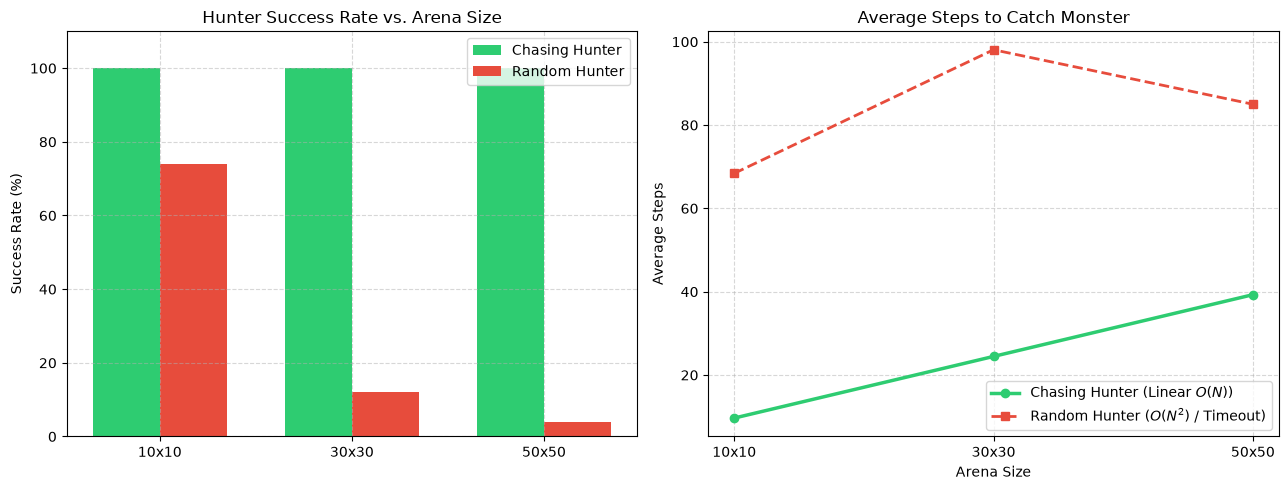

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

print("Running GridHunt Experiments across arena sizes 10x10, 30x30, and 50x50 (100 runs each)...")

def evaluate_hunter(hunter_fn, arena_sizes=[10, 30, 50], num_runs=100, max_steps=200):
    results = []
    for n in arena_sizes:
        steps_list = []
        for _ in range(num_runs):
            if hasattr(hunter_fn, 'reset'):
                hunter_fn.reset()
            s = arena_environment(hunter_fn, monster_agent_function_simple, n=n, max_steps=max_steps, visualize=False)
            steps_list.append(s)
        steps_arr = np.array(steps_list)
        failed = int(np.sum(np.isnan(steps_arr)))
        success = num_runs - failed
        avg_steps = round(float(np.nanmean(steps_arr)), 2) if success > 0 else np.nan
        results.append({
            "Arena Size": f"{n}x{n}",
            "Success Rate (%)": round(success / num_runs * 100, 1),
            "Failed Runs": failed,
            "Avg Steps (Success)": avg_steps
        })
    return pd.DataFrame(results)

df_chasing = evaluate_hunter(chasing_hunter_agent, arena_sizes=[10, 30, 50], num_runs=100, max_steps=200)
df_chasing["Agent"] = "Chasing Hunter (Model-Based)"

df_random = evaluate_hunter(simple_randomized_hunter_agent_function, arena_sizes=[10, 30, 50], num_runs=100, max_steps=200)
df_random["Agent"] = "Randomized Hunter"

df_comparison = pd.concat([df_chasing, df_random], ignore_index=True)
display(df_comparison[["Agent", "Arena Size", "Success Rate (%)", "Failed Runs", "Avg Steps (Success)"]])

# Truc quan hoa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Bieu do 1: So sanh ty le thanh cong
sizes = ["10x10", "30x30", "50x50"]
x = np.arange(len(sizes))
w = 0.35

ax1.bar(x - w/2, df_chasing["Success Rate (%)"], width=w, label="Chasing Hunter", color="#2ecc71")
ax1.bar(x + w/2, df_random["Success Rate (%)"], width=w, label="Random Hunter", color="#e74c3c")
ax1.set_xticks(x)
ax1.set_xticklabels(sizes)
ax1.set_ylabel("Success Rate (%)")
ax1.set_title("Hunter Success Rate vs. Arena Size")
ax1.set_ylim(0, 110)
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.5)

# Bieu do 2: So buoc trung binh de bat quai vat
chasing_steps = df_chasing["Avg Steps (Success)"]
random_steps = df_random["Avg Steps (Success)"].fillna(200)

ax2.plot(sizes, chasing_steps, marker="o", linewidth=2.5, color="#2ecc71", label="Chasing Hunter (Linear $O(N)$)")
ax2.plot(sizes, random_steps, marker="s", linewidth=2, linestyle="--", color="#e74c3c", label="Random Hunter ($O(N^2)$ / Timeout)")
ax2.set_ylabel("Average Steps")
ax2.set_xlabel("Arena Size")
ax2.set_title("Average Steps to Catch Monster")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Kết luận

Thảo luận các câu hỏi sau:

* Chiến lược cuối cùng của thợ săn để chọn hành động là gì? Vì sao chiến lược này hoạt động tốt?
* Bạn có dùng dịch chuyển không? Vì sao và trong tình huống nào? Nếu không, vì sao?
* Kích thước đấu trường ảnh hưởng thế nào đến hiệu quả của tác tử thợ săn?

### Kết luận và phân tích

1. **Chiến lược cuối cùng của thợ săn và lý do hiệu quả:**
   - Thợ săn đuổi bắt là một **tác tử phản xạ dựa trên mô hình**.
   - Vì môi trường chỉ cung cấp tọa độ quái vật nếu lượt trước chọn `listen`, tác tử không có bộ nhớ sẽ khó đuổi bắt hiệu quả.
   - Tác tử lưu tọa độ cuối cùng nhìn thấy của quái vật trong trạng thái nội bộ `last_monster_pos`.
   - Ở lượt đầu, tác tử chọn `listen`; các lượt sau di chuyển theo độ lệch Manhattan. Khi đến vị trí ghi nhớ, tác tử lại `listen` để cập nhật nếu quái vật đã di chuyển.

2. **Phân tích dịch chuyển:**
   - **Có sử dụng dịch chuyển không?** Không.
   - Dịch chuyển đặt thợ săn ở một tọa độ ngẫu nhiên. Khi đã biết vị trí mục tiêu, di chuyển có hướng luôn giảm khoảng cách, còn dịch chuyển có thể đưa thợ săn ra xa hơn.

3. **Ảnh hưởng của kích thước đấu trường:**
   - Với thợ săn đuổi bắt, số bước tăng gần tuyến tính $O(n)$ vì khoảng cách Manhattan tối đa tỷ lệ với $n$.
   - Với thợ săn ngẫu nhiên, thời gian bao phủ tăng gần bậc hai $O(n^2)$ nên dễ thất bại trong đấu trường lớn với giới hạn 200 bước.

Quái vật cũng là một tác tử. Hãy mô tả cách thay đổi hàm tác tử của quái vật để nó tránh thợ săn tốt hơn.

### Cải thiện tác tử quái vật

Tác tử hiện tại di chuyển hoàn toàn ngẫu nhiên và có 50% khả năng đứng yên. Để trốn tránh hiệu quả hơn, có thể nâng cấp thành một tác tử né tránh thông minh:

1. **Phản xạ né tránh:** Tính vectơ đẩy từ thợ săn đến quái vật và ưu tiên các hành động làm tăng khoảng cách Manhattan.
2. **Tránh tường và góc:** Nếu hướng chạy trực tiếp dẫn vào tường hoặc góc, chọn một hướng vuông góc để tránh bị dồn.
3. **Đứng yên có chiến lược:** Khi thợ săn ở xa, quái vật có thể đứng yên hoặc đi lang thang; khi thợ săn đến gần, quái vật chuyển sang né tránh tối đa và không chọn `stay`.

Chiến lược này biến trò chơi thành bài toán đuổi bắt và né tránh động, buộc thợ săn phải dồn quái vật vào góc hoặc bao vây nó.

# Mở rộng (tùy chọn)

Một số ý tưởng:

* Cài đặt tác tử quái vật tốt hơn và thực hiện thí nghiệm.
* Thay đổi môi trường để nhiều thợ săn cùng truy đuổi quái vật.
* Thêm hành động bắn mũi tên theo một hướng; mũi tên đi tối đa 5 ô và thợ săn thắng nếu bắn trúng quái vật.